## IDEAMAPS Data Ecosystem - Analysis of PAR results


This notebook analyzes the results of the Participatory Action Research (PAR) conducted within the IDEAMAPS Data Ecosystem project.

**Main objectives:**

1. **Compare PAR Validations with Model Outputs:** Visualize and analyze the agreement and disagreement between PAR participant validations and model outputs. This is done using visualisations such as pie charts, alluvial plots, and maps.

2. **Identify Areas of Confusion:** Highlight grid cells where PAR participants provided varying validations, indicating potential areas of confusion or ambiguity in the validation results. Ternary plots are used to visualize the distribution of these varying validations.

3. **Provide Insights for Model Improvement:** Use the analysis results to identify areas where the model needs improvement and to inform future iterations of the model development within the IDEAMAPS Data Ecosystem.

**Overall, this notebook provides a comprehensive analysis of the PAR results, offering valuable insights for understanding the performance of the model and guiding future development within the IDEAMAPS Data Ecosystem project.**

### **Contributing**
Members of the IDEAMAPS Data Ecosystem project are welcome to contribute to this notebook. When contributing - please follow the guidelines listed below.

**Code Hygiene Practices**:

1. **Use clear and descriptive variable names**: Choose variable names that accurately reflect their purpose and meaning. Avoid using single-letter or generic names.
2. **Write modular code**: Each cell should seek to acheive one task alone.
3. **Add comments to your code**: Explain the purpose and logic of your code using comments. This helps others understand your code and makes it easier to maintain.
4. **Follow consistent formatting**: Use a consistent coding style throughout the notebook. This improves readability and reduces visual clutter.
5. **Document your code**: Provide clear and concise documentation for your code, including explanations of its purpose, inputs, outputs, and any assumptions or limitations.


### Contact Points
For help or support with work related to this notebook - please contact either:
- Sebastian - sebastian.hafner@glasgow.ac.uk
- Andy - andrew.c.c.clarke@glasgow.ac.uk

In [51]:
!pip install mapboxgl
!pip install cartopy
!pip install contextily
!pip install rasterio
!pip install cartopy
!pip install mpltern
!pip install seaborn

In [52]:
# Import Modules
import pandas as pd
from pandas import json_normalize
import geopandas as gpd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import plotly.express as px
import plotly.graph_objects as go
import mpltern
import contextily as ctx
import rasterio
from rasterio.plot import show
from scipy.stats import mode
import seaborn as sns

import shapely
import mapboxgl
from mapboxgl.utils import create_color_stops
from mapboxgl.viz import ChoroplethViz

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.img_tiles import MapboxTiles
from cartopy.io.img_tiles import OSM

import json
import ast
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [19]:
# Load the validation dataset
validation_df = pd.read_csv('2026-01-27T09_11_45+00_00_0912.csv')
print(validation_df.shape)
validation_df.head()

(90301, 14)


,id,created_at,validation,user_id,user_background,user_map_usage,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude
0,51c48ebe-f38f-4500-a80c-5ec1ac80bdca,2025-05-08T14:40:28.368385+00:00,1.0,a1c71b2b-d878-4e05-bae0-d4a1be92242b,['Just Browsing'],4.0,b37ec964-ce74-4c35-a465-12f8e97ff7bf,08a139b4-f2ef-4758-9969-860c7e889db0,Nairobi,Kenya,Accumulated Waste Piles,1,-1.286387,36.827204
1,0063f12d-3f04-47df-b7e0-3c55adbc09db,2025-05-22T12:36:28.908012+00:00,2.0,4466ebba-9700-4d0f-808d-a661cb693746,NaN,4.0,6e006408-ef2a-4b9c-bdac-15c737a14be7,6f38f125-0d6f-4b7f-9cb0-e3529e67da75,Kano,Nigeria,Morphological Informality,2,11.996518,8.508990
2,934f028f-6e1b-4029-ab07-f41b269b204e,2025-05-22T12:41:19.334276+00:00,1.0,15aa12bd-f20b-4a40-a1d8-5d57ae17eb1a,"['Just Browsing', 'Someone Different', 'gentle...",4.0,f80d0053-ede5-40fd-b2a6-dd1433d1eb1e,6f38f125-0d6f-4b7f-9cb0-e3529e67da75,Kano,Nigeria,Morphological Informality,0,11.993255,8.472513
3,651d9931-6988-429b-940c-a2c46cd445bc,2025-05-22T12:41:28.409779+00:00,1.0,15aa12bd-f20b-4a40-a1d8-5d57ae17eb1a,"['Just Browsing', 'Someone Different', 'gentle...",4.0,79d3eb25-b071-4613-9134-093cbb151e28,6f38f125-0d6f-4b7f-9cb0-e3529e67da75,Kano,Nigeria,Morphological Informality,0,11.994071,8.471518
4,936c8a66-c7de-4d67-922b-1ba05ba05f39,2025-05-22T12:41:32.881643+00:00,1.0,15aa12bd-f20b-4a40-a1d8-5d57ae17eb1a,"['Just Browsing', 'Someone Different', 'gentle...",4.0,162a97eb-3e5b-466d-93ff-a9e080943927,6f38f125-0d6f-4b7f-9cb0-e3529e67da75,Kano,Nigeria,Morphological Informality,0,11.994071,8.470506


In [20]:
# Select pilot city
pilot = 'Lagos'

In [21]:
# Load PAR data and filter by pilot city
par_expanded = validation_df[validation_df['output_model_city_name'] == f'{pilot.capitalize()}']

In [22]:
# Describe the shape of the validation data
print("Shape of PAR Data", par_expanded.shape)
par_expanded['output_model_subdomain_name'].value_counts()

Shape of PAR Data (36677, 14)


output_model_subdomain_name
Morphological Informality                      11449
Emergency Obstetric Care Access Deprivation     6174
Flood Hazard                                    6041
Road Access Deprivation                         5607
General Healthcare Access Deprivation           5312
Drinking Water Access Deprivation               2094
Name: count, dtype: int64

In [23]:
# Convert Dataframe to GeoDataFrame with Output Points x,y (geometry)
par = gpd.GeoDataFrame(par_expanded, geometry=gpd.points_from_xy(par_expanded.output_longitude, par_expanded.output_latitude), crs="EPSG:4326")
par.shape

(36677, 15)

In [24]:
# Load grid for the pilot city.
grid = gpd.read_file ('one-hour-cutoff-study-area.gpkg')

In [25]:
# Describe the shape of the validation data
print("Shape of PAR Data", par.shape)
par['output_model_subdomain_name'].value_counts()

Shape of PAR Data (36677, 15)


output_model_subdomain_name
Morphological Informality                      11449
Emergency Obstetric Care Access Deprivation     6174
Flood Hazard                                    6041
Road Access Deprivation                         5607
General Healthcare Access Deprivation           5312
Drinking Water Access Deprivation               2094
Name: count, dtype: int64

In [26]:
# Enter subdomain
subdomain = 'Drinking Water Access Deprivation'

# Filter Data by Subdomain
par_subdomain = par[par['output_model_subdomain_name'] == subdomain]
par_subdomain.head()

,id,created_at,validation,user_id,user_background,user_map_usage,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude,geometry
86652,f4fd5884-4f0c-447a-a770-8ca60682588e,2026-01-19T13:36:39.843778+00:00,2.0,dc0538f9-d2b3-4109-8116-b429cbebfecd,['Community Member'],2.0,c8684b02-8df0-42be-a3d7-a91e7cd6a703,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.607992,3.409929,POINT (3.40993 6.60799)
86662,3f998ad6-98bf-46a5-ae11-43303efca13f,2026-01-19T13:37:50.664284+00:00,2.0,d6f1f42d-d5d2-4917-9d3c-3e521292bb2f,NaN,2.0,68d77f3f-8165-4845-8b5e-31b07cd12937,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.604748,3.416929,POINT (3.41693 6.60475)
86674,6bcdb870-a47e-4c6b-83a1-b2f052017006,2026-01-19T13:38:16.554319+00:00,1.0,b7085b3b-71ca-4479-bf70-4335856cf086,NaN,2.0,64f88ea1-79b8-473c-ae3b-129610a31e24,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.604748,3.415927,POINT (3.41593 6.60475)
86675,78a7cec3-433d-496f-a73e-9552cdd22f41,2026-01-19T13:38:25.728696+00:00,2.0,dc0538f9-d2b3-4109-8116-b429cbebfecd,['Community Member'],2.0,15c6ba72-a907-4b96-992e-bb4000b482b6,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.605559,3.409919,POINT (3.40992 6.60556)
86681,e484ee53-3376-44ea-ad72-8df989ee0585,2026-01-19T13:23:10.076725+00:00,1.0,b2559219-c7d6-47be-b589-0f58fda8686f,['Community Member'],2.0,9b8314af-f480-4997-a030-79bedeb29d66,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,0,6.601505,3.427936,POINT (3.42794 6.60151)


In [27]:
par_subdomain = par_subdomain.copy()

par_subdomain['grid_cells_agreed'] = (par_subdomain['validation'] == par_subdomain['output_result']).astype(int)
par_subdomain['grid_cells_changed'] = (par_subdomain['validation'] != par_subdomain['output_result']).astype(int)

par_subdomain['date'] = pd.to_datetime(par_subdomain['created_at']).dt.date
validation_dates = par_subdomain['date'].sort_values().unique()

summary_total = {
    "users_validating": par_subdomain['user_id'].nunique(),
    "total_validated_cells": par_subdomain['id'].count(),
    "grid_cells_agreed": par_subdomain['grid_cells_agreed'].sum(),
    "grid_cells_changed": par_subdomain['grid_cells_changed'].sum(),
    "validation_dates": validation_dates.tolist()
}

print(summary_total)

{'users_validating': 16, 'total_validated_cells': 2094, 'grid_cells_agreed': 800, 'grid_cells_changed': 1294, 'validation_dates': [datetime.date(2026, 1, 19), datetime.date(2026, 1, 20), datetime.date(2026, 1, 22), datetime.date(2026, 1, 23)]}


In [28]:
# Dates you want (session dates)
session_dates = pd.to_datetime(["2026-1-19", "2026-1-20", "2026-1-22", "2026-1-23"]).date  # array of python dates

# Ensure created_at is datetime
par_subdomain = par_subdomain.copy()
par_subdomain["created_at"] = pd.to_datetime(par_subdomain["created_at"], errors="coerce", utc=True)

# Filter rows whose created_at date matches the session dates
par_df = par_subdomain[par_subdomain["created_at"].dt.date.isin(session_dates)]

# Check result
par_df.shape


(2094, 18)

In [29]:
par_subdomain["created_at"].dtype
par_subdomain["created_at"].isna().sum()   # if >0, you have bad timestamps
par_subdomain["created_at"].dt.date.value_counts().head(10)


created_at
2026-01-19    2051
2026-01-20      19
2026-01-22      19
2026-01-23       5
Name: count, dtype: int64

In [30]:
# Count how many validations are labeled as Low, Medium, or High by PAR participants
count_validations = par_df['validation'].value_counts()

# Count how many model outputs are labeled as Low, Medium, or High by the model
count_outputs = par_df['output_result'].value_counts()

# Display counts for both, with a key for category codes
print('Key = [0: Low; 1: Medium; 2: High]\nValidations\n', count_validations)
print('\nModel Outputs\n', count_outputs)

Key = [0: Low; 1: Medium; 2: High]
Validations
 validation
1.0    996
2.0    635
0.0    463
Name: count, dtype: int64

Model Outputs
 output_result
1    1129
0     962
2       3
Name: count, dtype: int64


In [31]:
# Set configuration for parameter mapping and visualization aesthetics

# 1. Semantic mapping of categorical levels
par_key = {0: "Low", 1: "Medium", 2: "High"}

# 2. Color palette mapping for categorical levels
color_palette = {
  '0': '#0080FF',  # Blue for low
  '1': '#FFB300',  # Yellow for medium
  '2': '#FF4B77'   # Pink for high
}
par['created_at'] = pd.to_datetime(par['created_at'])

# **General analysis**

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


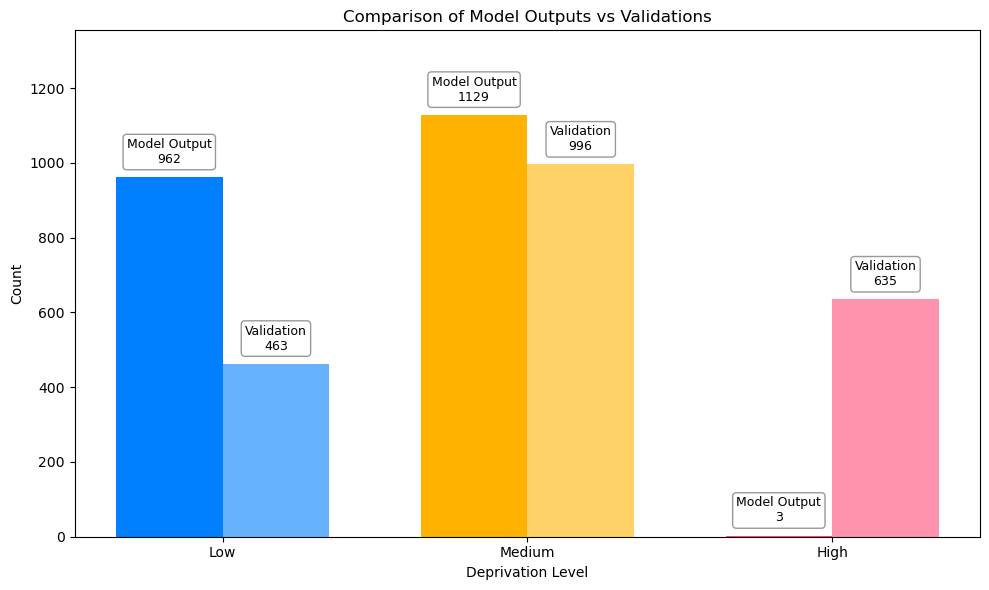

In [32]:
# ## Comparative Bar Plot: Model Outputs vs PAR Validation

# Convert color_palette keys from strings to integers for consistent indexing
color = [color_palette[str(i)] for i in range(3)]

# Prepare ordered category labels and their corresponding counts,
# Missing categories are filled with zero to ensure correct alignment between model outputs and validations.
labels = [par_key[i] for i in range(3)]
outputs = [count_outputs.get(i, 0) for i in range(3)]
validations = [count_validations.get(i, 0) for i in range(3)]

# Define bar positions on the x-axis and width for grouped bars
x = np.arange(len(labels))
width = 0.35

# Create the plotting figure and axis with specified size
fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars for model outputs with solid colors
bars1 = ax.bar(x - width/2, outputs, width,
               color=[color_palette[str(i)] for i in range(3)])

# Plot bars for validations with the same colors but semi-transparent
bars2 = ax.bar(x + width/2, validations, width,
               color=[color_palette[str(i)] for i in range(3)], alpha=0.6)

# Set axis labels and chart title
ax.set_xlabel('Deprivation Level')
ax.set_ylabel('Count')
ax.set_title('Comparison of Model Outputs vs Validations')

# Assign category labels to the x-axis ticks
ax.set_xticks(x)
ax.set_xticklabels(labels)

# Remove the legend to avoid redundancy since labels are annotated directly on bars
ax.legend().remove()

# Dynamically set y-axis limit with extra space to accommodate labels above bars
max_height = max(max(outputs), max(validations))
ax.set_ylim(0, max_height * 1.2)  # Extend y-axis by 20% above the tallest bar

# Define a helper function to annotate each bar with a label and its count value,
# placing a white rounded box slightly above the bar for clarity.
def add_labels_with_type(bars, label_text):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{label_text}\n{height}',          # Label type and count on two lines
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 8),                      # Vertical offset above the bar
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white",
                      alpha=0.8,
                      edgecolor="gray")
        )

# Apply annotations to both model output bars and validation bars
add_labels_with_type(bars1, "Model Output")
add_labels_with_type(bars2, "Validation")

plt.tight_layout()
plt.show()

In [33]:
# Create alluvial plot to show change in distribution between model output x PAR validation
# Group by the two columns and count the occurrences
data = par_df.groupby(['output_result', 'validation']).size().reset_index(name='Count')

levels = list(par_key.keys())
level_labels = list(par_key.values())

# Create source and target for the Sankey diagram
source = data['output_result'].apply(lambda x: levels.index(x)).tolist()
target = data['validation'].apply(lambda x: levels.index(x) + len(levels)).tolist()
counts = data['Count'].tolist()

# Generate colors for the nodes
color_list = list(color_palette.values())

# Ensure same color for corresponding categories in Category1 and Category2
node_colors = color_list[:len(levels)] + color_list[:len(levels)]
link_colors = [node_colors[src] for src in source]

# Create the alluvial plot using plotly
fig = go.Figure(go.Sankey(
    node=dict(
        pad=5,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=2 * level_labels,
        color=node_colors  # Apply node colors
    ),
    link=dict(
        source=source,
        target=target,
        value=counts,
        color=link_colors  # Ensure the links have matching colors
    )
))

# Update layout to reduce the width of the plot
fig.update_layout(
    title_text="Redistribution of Dataset According to PAR Validations",
    font_size=14,
    height=600,
)

fig.show()

In [34]:
# Aggregating Validation Counts per Spatial Grid Cell

# Group by latitude and longitude, and count validations per subdomain
val_count_cols = [f'val_count_{n}' for n in range(3)]
def output_count(data):  # Data is all entries for a grid cell (group)

  # Count occurrences of each validation category
  val_0 = data.loc[(data['validation'] == 0), 'validation'].count()
  val_1 = data.loc[(data['validation'] == 1), 'validation'].count()
  val_2 = data.loc[(data['validation'] == 2), 'validation'].count()

# If result values differ, take the mode (most frequent value)
  if len(set(data['output_result'])) == 1:
        model = list(data['output_result'])[0]
  else:
        mode_result = mode(data['output_result'])
        if isinstance(mode_result.mode, np.ndarray):
            model = mode_result.mode[0]
        else:
            model = mode_result.mode

  return pd.Series([val_0, val_1, val_2, model], index=val_count_cols + ['model'])

# 1. Group data by latitude and longitude, then compute counts and model prediction
par_counts = par_df.groupby(['output_latitude', 'output_longitude']).apply(output_count).reset_index()

# 2. Compute the total number of validations per cell and the maximum count among categories
par_counts['val_total'] = par_counts[val_count_cols].sum(axis=1)
par_counts['val_max'] = par_counts[val_count_cols].max(axis=1)

# 3. Identify whether multiple validation categories occur within the same cell
par_counts['val_vary'] = par_counts.apply(lambda row: 1 if row['val_total'] != row['val_max'] else 0, axis=1)

# 4. Create Shapely Point geometries from longitude and latitude
par_counts['geometry'] = par_counts.apply(lambda row: shapely.Point([row['output_longitude'], row['output_latitude']]), axis=1)

# 5. Set coordinate reference system to WGS 84 (EPSG:4326)
par_counts = gpd.GeoDataFrame(par_counts, geometry='geometry', crs='EPSG:4326')

# 6. Create a GeoDataframe by joining the PAR counts to the city grid
par_gdf = gpd.sjoin(grid.to_crs(4326), par_counts, how="left", predicate='contains')
par_gdf = par_gdf.dropna(subset=['index_right'])[par_counts.columns]
print(par_gdf.shape)
par_gdf.head()

(543, 10)


/var/folders/y0/vlr9p1691nzbmnxt09fwc1nw0000gp/T/ipykernel_57074/426216396.py:25: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,output_latitude,output_longitude,val_count_0,val_count_1,val_count_2,model,val_total,val_max,val_vary,geometry
27285,6.604748,3.405908,0.0,1.0,0.0,1.0,1.0,1.0,0.0,"POLYGON ((3.40541 6.60515, 3.40641 6.60515, 3...."
27399,6.607992,3.407926,0.0,0.0,2.0,1.0,2.0,2.0,0.0,"POLYGON ((3.40743 6.6084, 3.40843 6.6084, 3.40..."
27400,6.607181,3.407922,0.0,2.0,4.0,1.0,6.0,4.0,1.0,"POLYGON ((3.40742 6.60759, 3.40842 6.60759, 3...."
27401,6.606370,3.407919,0.0,2.0,1.0,1.0,3.0,2.0,1.0,"POLYGON ((3.40742 6.60678, 3.40842 6.60678, 3...."
27402,6.605559,3.407915,1.0,1.0,0.0,1.0,2.0,1.0,1.0,"POLYGON ((3.40742 6.60596, 3.40842 6.60596, 3...."


In [35]:
cell_agg = (
    par_gdf
    .groupby(par_gdf.index)[val_count_cols + ['model']]
    .agg({
        'val_count_0': 'sum',
        'val_count_1': 'sum',
        'val_count_2': 'sum',
        'model': lambda x: x.mode().iloc[0]
    })
)

cell_agg['val_total'] = cell_agg[val_count_cols].sum(axis=1)
cell_agg['val_max'] = cell_agg[val_count_cols].max(axis=1)
cell_agg['val_vary'] = cell_agg.apply(
    lambda row: 1 if row['val_total'] != row['val_max'] else 0,
    axis=1
)

def find_majority(row):
    max_value = row.max()
    max_columns = row[row == max_value].index
    if len(max_columns) == 1:
        return int(max_columns[0].split('_')[-1])
    return np.nan

cell_agg['val_majority'] = cell_agg[val_count_cols].apply(find_majority, axis=1)

par_gdf_cell = gpd.GeoDataFrame(
    cell_agg.join(grid.geometry),
    geometry='geometry',
    crs='EPSG:4326'
)

par_gdf_map = par_gdf_cell.dropna(subset=['val_majority'])
par_gdf_map = gpd.GeoDataFrame(par_gdf_map, geometry='geometry', crs='EPSG:4326')

In [36]:
# Use majority voting to handle cells with multiple validations
def find_majority(row):
    max_value = row.max()
    max_columns = row[row == max_value].index
    if len(max_columns) == 1:  # Only one column has the max value
        return int(max_columns[0][-1])
    return np.nan  # Tie or no clear majority
par_gdf['val_majority'] = par_gdf[val_count_cols].apply(find_majority, axis=1)

par_gdf = par_gdf.astype({
  'val_count_0': 'uint8',
  'val_count_1': 'uint8',
  'val_count_2': 'uint8',
  'model': 'uint8',
  'val_total': 'uint8',
  'val_max': 'uint8',
  'val_vary': 'uint8',
  'val_majority': pd.Int64Dtype()
})

# Remove cells with no concensus
par_gdf_map = par_gdf.dropna(subset=['val_majority'])
par_gdf_map = gpd.GeoDataFrame(par_gdf_map, geometry='geometry', crs='EPSG:4326')

In [37]:
df_eval = par_gdf.dropna(subset=['val_majority'])

y_true = df_eval['val_majority'].astype(int)
y_pred = df_eval['model'].astype(int)

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc*100:.3f}%")

# F1 Score
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')
print(f"Macro F1: {f1_macro:.3f}, Weighted F1: {f1_weighted:.3f}")

# Precision/Recall/F1
report = classification_report(
    y_true, y_pred,
    labels=[0,1,2],
    target_names=['Low','Medium','High'],
    digits=3
)
print(report)

Accuracy: 29.314%
Macro F1: 0.230, Weighted F1: 0.238
              precision    recall  f1-score   support

         Low      0.185     0.500     0.271        56
      Medium      0.349     0.456     0.396       206
        High      0.667     0.012     0.024       161

    accuracy                          0.293       423
   macro avg      0.401     0.323     0.230       423
weighted avg      0.448     0.293     0.238       423



In [38]:
par_gdf_map.to_file(f'par-majority-{pilot.lower()}-{subdomain}.gpkg', driver='GPKG')

In [39]:
#TO GET GRID LEVEL VALIDATION CELLS
print(par_gdf_map.columns.tolist())

['output_latitude', 'output_longitude', 'val_count_0', 'val_count_1', 'val_count_2', 'model', 'val_total', 'val_max', 'val_vary', 'geometry', 'val_majority']


In [40]:
print(len(par_gdf_map))

423


In [41]:
print(par_gdf_map[["model", "val_majority"]].isna().sum())
print(len(par_gdf_map))

model           0
val_majority    0
dtype: int64
423


In [42]:
shared_ymax = 1500

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


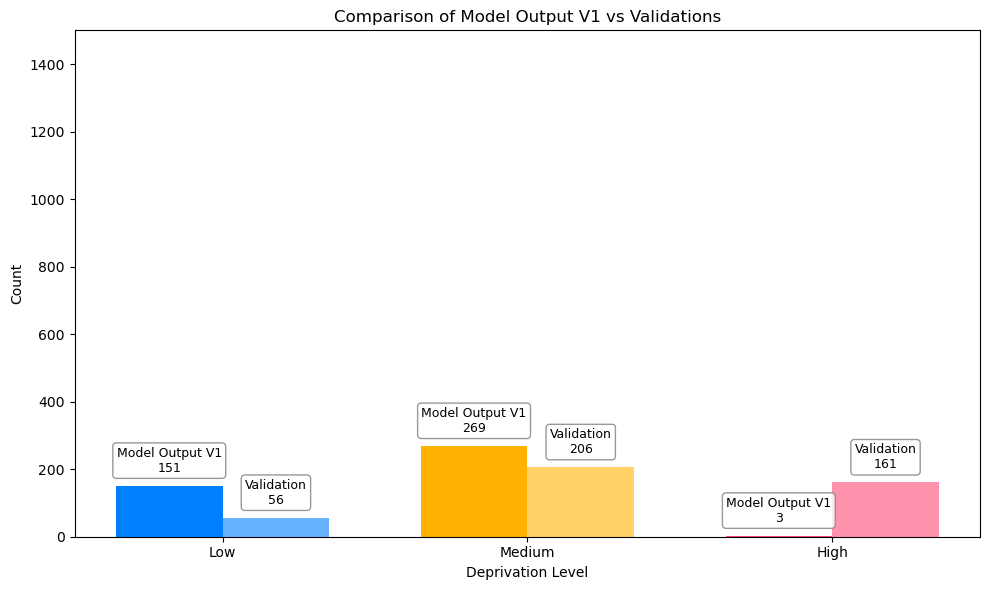

In [43]:
# ## Comparative Bar Plot: Model Output V1 vs PAR Validation (Kano, 1474 validated grid cells)

# Use the validated grid-cell layer, not individual validation responses
count_outputs_v1 = par_gdf_map["model"].astype(int).value_counts().to_dict()
count_validations_v1 = par_gdf_map["val_majority"].astype(int).value_counts().to_dict()

# Convert color_palette keys from strings to integers for consistent indexing
color = [color_palette[str(i)] for i in range(3)]

# Prepare ordered category labels and corresponding counts
labels = [par_key[i] for i in range(3)]
outputs_v1 = [count_outputs_v1.get(i, 0) for i in range(3)]
validations_v1 = [count_validations_v1.get(i, 0) for i in range(3)]

# Define bar positions and width
x = np.arange(len(labels))
width = 0.35

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars for model output V1
bars1 = ax.bar(
    x - width/2, outputs_v1, width,
    color=[color_palette[str(i)] for i in range(3)]
)

# Plot bars for validation
bars2 = ax.bar(
    x + width/2, validations_v1, width,
    color=[color_palette[str(i)] for i in range(3)],
    alpha=0.6
)

# Labels and title
ax.set_xlabel('Deprivation Level')
ax.set_ylabel('Count')
ax.set_title('Comparison of Model Output V1 vs Validations')

# X-axis ticks
ax.set_xticks(x)
ax.set_xticklabels(labels)

# Remove legend
ax.legend().remove()

# Set y-axis limit
ax.set_ylim(0, shared_ymax)

# Annotate bars
def add_labels_with_type(bars, label_text):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{label_text}\n{int(height)}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 8),
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=9,
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                alpha=0.8,
                edgecolor="gray"
            )
        )

add_labels_with_type(bars1, "Model Output V1")
add_labels_with_type(bars2, "Validation")

plt.tight_layout()
plt.show()

In [44]:
agreed_cells = (par_gdf_map["model"] == par_gdf_map["val_majority"]).sum()
changed_cells = (par_gdf_map["model"] != par_gdf_map["val_majority"]).sum()

total_cells = len(par_gdf_map)

print("Validated grid cells:", total_cells)
print("Agreed grid cells:", agreed_cells)
print("Changed grid cells:", changed_cells)

Validated grid cells: 423
Agreed grid cells: 124
Changed grid cells: 299


In [45]:
import pandas as pd
import plotly.graph_objects as go

# Use the 1474 validated grid cells
# This dataframe should contain: val_majority, model, model_v2
alluvial_df = par_gdf_map.copy()

# Ensure integer class codes
alluvial_df["val_majority"] = alluvial_df["val_majority"].astype(int)
alluvial_df["model"] = alluvial_df["model"].astype(int)

levels = list(par_key.keys())          # [0, 1, 2]
level_labels = list(par_key.values())  # ['Low', 'Medium', 'High']
color_list = [color_palette[str(i)] for i in levels]

In [46]:
# Group by V1 model output and validation majority class
data_v1 = (
    alluvial_df.groupby(["model", "val_majority"])
    .size()
    .reset_index(name="Count")
)

# Sankey source/target
source_v1 = data_v1["model"].apply(lambda x: levels.index(x)).tolist()
target_v1 = data_v1["val_majority"].apply(lambda x: levels.index(x) + len(levels)).tolist()
counts_v1 = data_v1["Count"].tolist()

# Node colors
node_colors_v1 = color_list + color_list
link_colors_v1 = [node_colors_v1[src] for src in source_v1]

fig_v1 = go.Figure(go.Sankey(
    node=dict(
        pad=5,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=2 * level_labels,
        color=node_colors_v1
    ),
    link=dict(
        source=source_v1,
        target=target_v1,
        value=counts_v1,
        color=link_colors_v1
    )
))

fig_v1.update_layout(
    title_text="Alluvial Plot: Model Output V1 vs PAR Validation (Kano, 1474 validated grid cells)",
    font_size=14,
    height=600,
)

fig_v1.show()

In [47]:
# Mapbox token
px.set_mapbox_access_token(
    "pk.eyJ1IjoiYW5keWNsYXJrZSIsImEiOiJjbDFvd2Y2eXcwM2ljM2NxdTU3Z2lpNmhhIn0.z5Et74WK71oansNVN5oDYQ"
)

# --- 1) Sanity: compute Kano center from geometry (NO hardcoding Lagos) ---
bounds = par_gdf_map.total_bounds  # [minx, miny, maxx, maxy]
center_lon = (bounds[0] + bounds[2]) / 2
center_lat = (bounds[1] + bounds[3]) / 2

# --- 2) Ensure correct dtypes for discrete colouring ---
par_gdf_map = par_gdf_map.copy()
par_gdf_map["model"] = par_gdf_map["model"].astype(str)
par_gdf_map["val_majority"] = par_gdf_map["val_majority"].astype(str)

# --- 3) Validation map (majority vote) ---
fig = px.choropleth_mapbox(
    par_gdf_map,
    geojson=par_gdf_map.geometry,
    locations=par_gdf_map.index,
    color="val_majority",
    color_discrete_map=color_palette,
    mapbox_style="mapbox://styles/andyclarke/cl4nznypi004i14s7qd086rbc",
    zoom=12,
    center={"lat": center_lat, "lon": center_lon},
    opacity=0.5,
)

fig.update_layout(
    title="PAR Validations (Lagos) 👇",
    height=1000,
    margin={"r": 0, "t": 50, "l": 0, "b": 50},
)
fig.show()

# --- 4) Model output map ---
fig2 = px.choropleth_mapbox(
    par_gdf_map,
    geojson=par_gdf_map.geometry,
    locations=par_gdf_map.index,
    color="model",
    color_discrete_map=color_palette,
    mapbox_style="mapbox://styles/andyclarke/cl4nznypi004i14s7qd086rbc",
    zoom=12,
    center={"lat": center_lat, "lon": center_lon},
    opacity=0.5,
)

fig2.update_layout(
    title="Model Output (Lagos) 👇",
    height=1000,
    margin={"r": 0, "t": 50, "l": 0, "b": 50},
)
fig2.show()


In [48]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report

# use same validated cells
df_eval = par_gdf_map.dropna(subset=['val_majority', 'model']).copy()

y_true = df_eval["val_majority"].astype(int)
y_pred = df_eval["model"].astype(int)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average="weighted")

print("Confusion Matrix (Kano V2):")
print(cm)
print(f"Total cells: {len(df_eval)}\n")

print(f"Accuracy: {acc:.3f}")
print(f"Macro F1: {macro_f1:.3f}")
print(f"Weighted F1: {weighted_f1:.3f}\n")

print("Classification Report")
print(classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2],
    target_names=["Low", "Medium", "High"],
    digits=3
))

Confusion Matrix (Kano V2):
[[ 28  28   0]
 [111  94   1]
 [ 12 147   2]]
Total cells: 423

Accuracy: 0.293
Macro F1: 0.230
Weighted F1: 0.238

Classification Report
              precision    recall  f1-score   support

         Low      0.185     0.500     0.271        56
      Medium      0.349     0.456     0.396       206
        High      0.667     0.012     0.024       161

    accuracy                          0.293       423
   macro avg      0.401     0.323     0.230       423
weighted avg      0.448     0.293     0.238       423



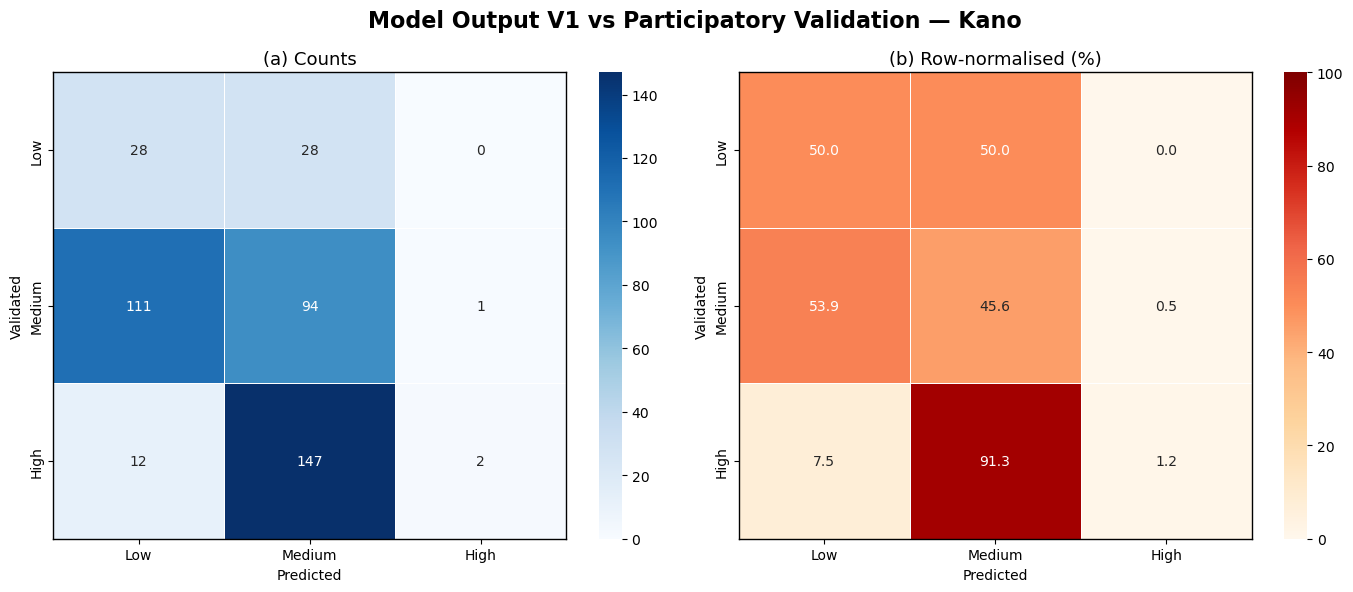

In [53]:
cm_df = pd.DataFrame(
    cm,
    index=['Low', 'Medium', 'High'],
    columns=['Low', 'Medium', 'High']
)

cm_pct = cm_df.div(cm_df.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------- Counts --------
sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    ax=axes[0],
    linewidths=0.6,
    linecolor='white'
)

axes[0].set_title('(a) Counts', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Validated')

# BLACK OUTER BORDER
for spine in axes[0].spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1)

# -------- Percentages --------
sns.heatmap(
    cm_pct,
    annot=True,
    fmt='.1f',
    cmap='OrRd',
    cbar=True,
    ax=axes[1],
    linewidths=0.6,
    linecolor='white',
    vmin=0,
    vmax=100
)

axes[1].set_title('(b) Row-normalised (%)', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Validated')

# BLACK OUTER BORDER
for spine in axes[1].spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1)

fig.suptitle(
    'Model Output V1 vs Participatory Validation — Kano',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

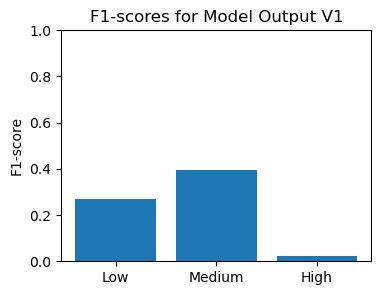

In [54]:
import matplotlib.pyplot as plt

f1_scores = {
    "Low": 0.271,
    "Medium": 0.396,
    "High": 0.024
}

fig, ax = plt.subplots(figsize=(4,3))
ax.bar(f1_scores.keys(), f1_scores.values())
ax.set_ylim(0,1)
ax.set_ylabel("F1-score")
ax.set_title("F1-scores for Model Output V1")

plt.show()